In [1]:
#!pip install ema_workbench

In [2]:
#!pip install ipython-autotime
%load_ext autotime

time: 331 µs (started: 2023-10-30 21:59:32 -03:00)


In [3]:
#import warnings
#warnings.simplefilter('module')

time: 223 µs (started: 2023-10-30 21:59:32 -03:00)


## **Simple Example (lake model)**

In [4]:
import math

# more or less default imports when using the workbench
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.optimize import brentq

def get_antropogenic_release(xt, c1, c2, r1, r2, w1):
    '''

    Parameters
    ----------
    xt : float
         polution in lake at time t
    c1 : float
         center rbf 1
    c2 : float
         center rbf 2
    r1 : float
         ratius rbf 1
    r2 : float
         ratius rbf 2
    w1 : float
         weight of rbf 1

    Returns
    -------
    float

    note:: w2 = 1 - w1

    '''

    rule = w1*(abs(xt-c1)/r1)**3+(1-w1)*(abs(xt-c2)/r2)**3
    at1 = max(rule, 0.01)
    at = min(at1, 0.1)

    return at


def lake_model(b=0.42, q=2.0, mean=0.02,
               stdev=0.001, delta=0.98, alpha=0.4,
               nsamples=100, myears=100, c1=0.25,
               c2=0.25, r1=0.5, r2=0.5,
               w1=0.5, seed=None):
    '''runs the lake model for nsamples stochastic realisation using
    specified random seed.

    Parameters
    ----------
    b : float
        decay rate for P in lake (0.42 = irreversible)
    q : float
        recycling exponent
    mean : float
            mean of natural inflows
    stdev : float
            standard deviation of natural inflows
    delta : float
            future utility discount rate
    alpha : float
            utility from pollution
    nsamples : int, optional
    myears : int, optional
    c1 : float
    c2 : float
    r1 : float
    r2 : float
    w1 : float
    seed : int, optional
           seed for the random number generator

    Returns
    -------
    tuple

    '''
    np.random.seed(seed)
    Pcrit = brentq(lambda x: x**q/(1+x**q) - b*x, 0.01, 1.5)

    X = np.zeros((myears,))
    average_daily_P = np.zeros((myears,))
    reliability = 0.0
    inertia = 0
    utility = 0

    for _ in range(nsamples):
        X[0] = 0.0
        decision = 0.1

        decisions = np.zeros(myears,)
        decisions[0] = decision

        natural_inflows = np.random.lognormal(
            math.log(mean**2 / math.sqrt(stdev**2 + mean**2)),
            math.sqrt(math.log(1.0 + stdev**2 / mean**2)),
            size=myears)

        for t in range(1, myears):

            # here we use the decision rule
            decision = get_antropogenic_release(X[t-1], c1, c2, r1, r2, w1)
            decisions[t] = decision

            X[t] = (1-b)*X[t-1] + X[t-1]**q/(1+X[t-1]**q) + decision +\
                natural_inflows[t-1]
            average_daily_P[t] += X[t]/nsamples

        reliability += np.sum(X < Pcrit)/(nsamples*myears)
        inertia += np.sum(np.absolute(np.diff(decisions)
                                      < 0.02)) / (nsamples*myears)
        utility += np.sum(alpha*decisions*np.power(delta,
                                                   np.arange(myears))) / nsamples
    max_P = np.max(average_daily_P)
    return max_P, utility, inertia, reliability

time: 1.45 s (started: 2023-10-30 21:59:32 -03:00)


In [5]:
from ema_workbench import (RealParameter, ScalarOutcome, Constant, Model)
from ema_workbench import perform_experiments

model = Model('lakeproblem', function=lake_model)

#specify uncertainties
model.uncertainties = [RealParameter('b', 0.1, 0.45),
                       RealParameter('q', 2.0, 4.5),
                       RealParameter('mean', 0.01, 0.05),
                       RealParameter('stdev', 0.001, 0.005),
                       RealParameter('delta', 0.93, 0.99)]

# set levers
model.levers = [RealParameter("c1", -2, 2),
                RealParameter("c2", -2, 2),
                RealParameter("r1", 0, 2),
                RealParameter("r2", 0, 2),
                RealParameter("w1", 0, 1)]

#specify outcomes
model.outcomes = [ScalarOutcome('max_P'),
                  ScalarOutcome('utility'),
                  ScalarOutcome('inertia'),
                  ScalarOutcome('reliability')]

# override some of the defaults of the model
model.constants = [Constant('alpha', 0.41),
                   Constant('nsamples', 150),
                   Constant('myears', 100)]

time: 987 ms (started: 2023-10-30 21:59:33 -03:00)


In [6]:
from ema_workbench import (MultiprocessingEvaluator, ema_logging, perform_experiments)
ema_logging.log_to_stderr(ema_logging.INFO)

#with MultiprocessingEvaluator(model) as evaluator:
#    results = evaluator.perform_experiments(scenarios=1000, policies=3)
results = perform_experiments(model, scenarios=1000, policies=3)

[MainProcess/INFO] performing 1000 scenarios * 3 policies * 1 model(s) = 3000 experiments
100%|██████████████████████████████████████| 3000/3000 [04:24<00:00, 11.35it/s]
[MainProcess/INFO] experiments finished


time: 4min 24s (started: 2023-10-30 21:59:34 -03:00)


In [7]:
experiments, outcomes = results
print(experiments.shape)
print(list(outcomes.keys()))

(3000, 13)
['max_P', 'utility', 'inertia', 'reliability']
time: 551 µs (started: 2023-10-30 22:03:58 -03:00)


In [8]:
experiments.sample(10)

,b,delta,mean,q,stdev,c1,c2,r1,r2,w1,scenario,policy,model
2958,0.116891,0.973732,0.035901,2.783818,0.003990,1.698200,-1.332223,0.986634,0.224728,0.388122,961,2,lakeproblem
1437,0.266062,0.986727,0.014188,3.625846,0.003888,-1.089876,-0.229079,0.145799,1.217292,0.974191,440,1,lakeproblem
2552,0.344379,0.938588,0.032559,2.911742,0.004723,1.698200,-1.332223,0.986634,0.224728,0.388122,555,2,lakeproblem
898,0.280233,0.945676,0.021308,2.743546,0.004294,-0.577145,1.341436,1.735666,1.996273,0.234034,901,0,lakeproblem
1231,0.229555,0.958493,0.046436,3.698129,0.003322,-1.089876,-0.229079,0.145799,1.217292,0.974191,234,1,lakeproblem
697,0.426265,0.932327,0.028935,3.016688,0.001043,-0.577145,1.341436,1.735666,1.996273,0.234034,700,0,lakeproblem
951,0.410691,0.989848,0.019632,2.321278,0.002345,-0.577145,1.341436,1.735666,1.996273,0.234034,954,0,lakeproblem
490,0.255792,0.973118,0.044447,4.353876,0.004873,-0.577145,1.341436,1.735666,1.996273,0.234034,493,0,lakeproblem
405,0.143799,0.934950,0.032784,3.525708,0.004891,-0.577145,1.341436,1.735666,1.996273,0.234034,408,0,lakeproblem
2894,0.391820,0.944970,0.040094,4.174387,0.004422,1.698200,-1.332223,0.986634,0.224728,0.388122,897,2,lakeproblem


time: 27.6 ms (started: 2023-10-30 22:03:58 -03:00)


In [9]:
outcomes

{'max_P': array([6.01877012, 2.76200714, 7.76117745, ..., 0.46328582, 2.94295091,
        9.18308812]),
 'utility': array([0.71794807, 2.43983038, 1.52437946, ..., 0.77030815, 2.26131148,
        1.70338656]),
 'inertia': array([0.99, 0.99, 0.99, ..., 0.99, 0.99, 0.99]),
 'reliability': array([0.08      , 0.11746667, 0.06113333, ..., 1.        , 0.08      ,
        0.02      ])}

time: 5.23 ms (started: 2023-10-30 22:03:58 -03:00)


In [10]:
experiments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   b         3000 non-null   float64 
 1   delta     3000 non-null   float64 
 2   mean      3000 non-null   float64 
 3   q         3000 non-null   float64 
 4   stdev     3000 non-null   float64 
 5   c1        3000 non-null   float64 
 6   c2        3000 non-null   float64 
 7   r1        3000 non-null   float64 
 8   r2        3000 non-null   float64 
 9   w1        3000 non-null   float64 
 10  scenario  3000 non-null   category
 11  policy    3000 non-null   category
 12  model     3000 non-null   category
dtypes: category(3), float64(10)
memory usage: 286.6 KB
time: 27.6 ms (started: 2023-10-30 22:03:58 -03:00)


In [11]:
policies = experiments['policy']
data = pd.DataFrame(outcomes)
data['policy'] = policies

time: 2.54 ms (started: 2023-10-30 22:03:59 -03:00)


In [12]:
experiments['policy'] = experiments.policy.astype(str)

time: 2.43 ms (started: 2023-10-30 22:03:59 -03:00)


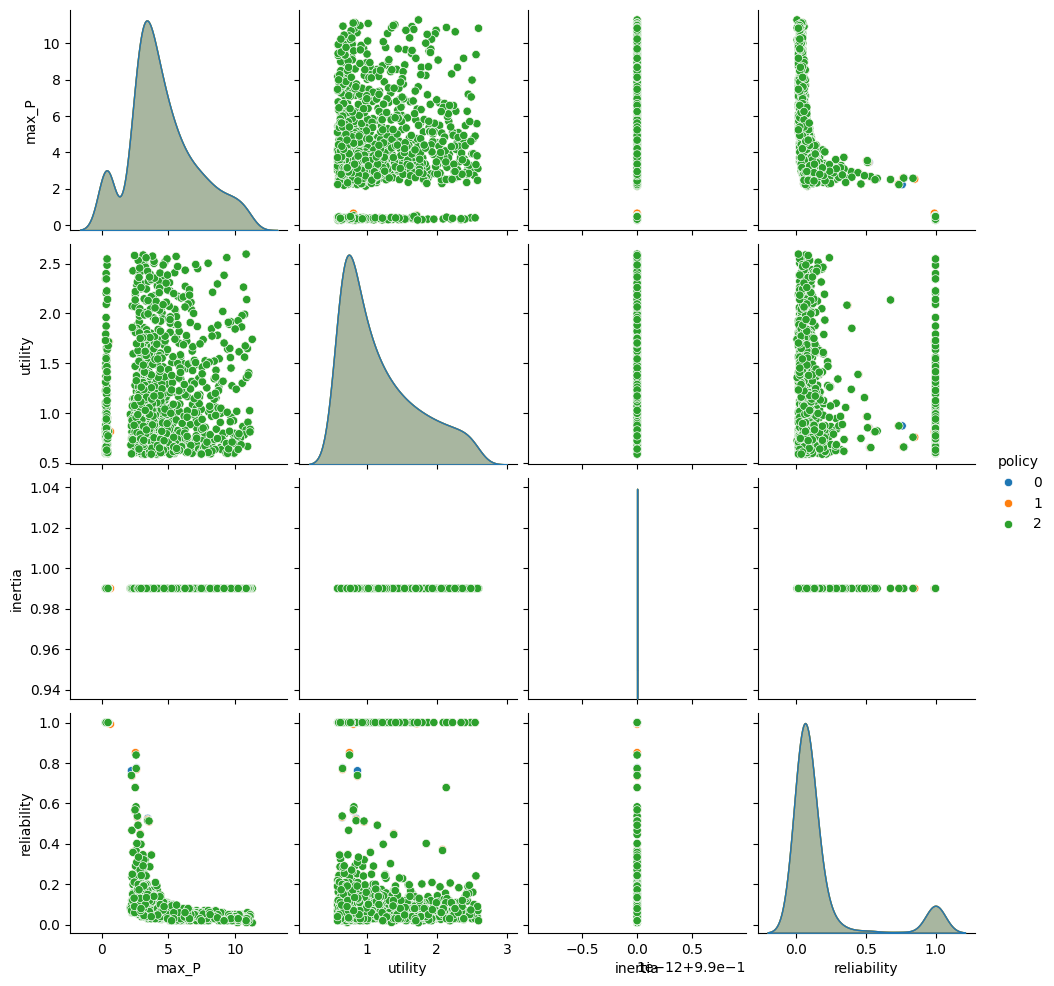

time: 5.86 s (started: 2023-10-30 22:03:59 -03:00)


In [13]:
sns.pairplot(data, hue='policy', vars=list(outcomes.keys()))
plt.show()

[MainProcess/INFO] no time dimension found in results


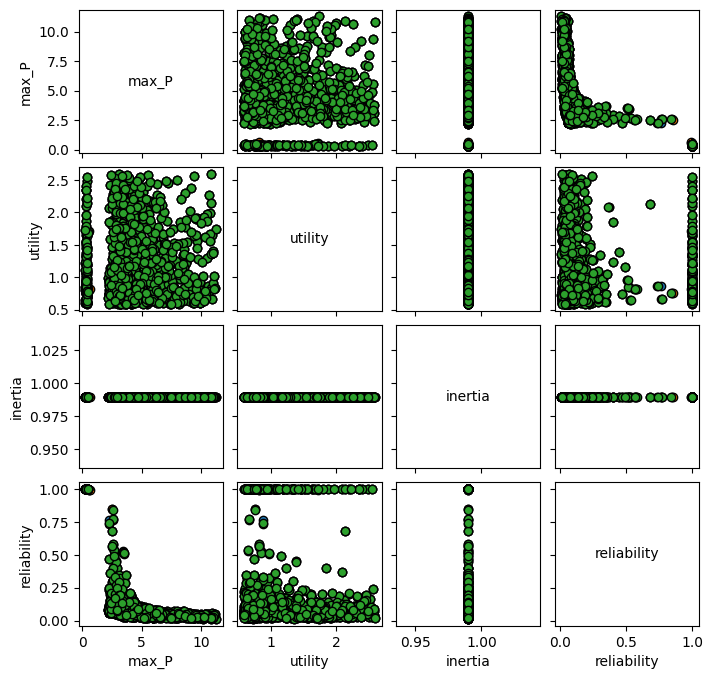

time: 4.85 s (started: 2023-10-30 22:04:04 -03:00)


In [14]:
from ema_workbench.analysis import pairs_plotting

fig, axes = pairs_plotting.pairs_scatter(experiments, outcomes, group_by='policy',
                                         legend=False)
fig.set_size_inches(8,8)
plt.show()

In [15]:
from ema_workbench import save_results
save_results(results, '1000 scenarios 5 policies.tar.gz')

from ema_workbench import load_results
results = load_results('1000 scenarios 5 policies.tar.gz')

[MainProcess/INFO] results saved successfully to /Users/adiazpace/Documents/my-research/explainability-cmu/robustness/1000 scenarios 5 policies.tar.gz
[MainProcess/INFO] results loaded successfully from /Users/adiazpace/Documents/my-research/explainability-cmu/robustness/1000 scenarios 5 policies.tar.gz


time: 257 ms (started: 2023-10-30 22:04:09 -03:00)


In [16]:
from ema_workbench.analysis import prim

x = experiments
y = outcomes['max_P'] <0.8
prim_alg = prim.Prim(x, y, threshold=0.8)
box1 = prim_alg.find_box()

[MainProcess/INFO] model dropped from analysis because only a single category
[MainProcess/INFO] 3000 points remaining, containing 288 cases of interest
[MainProcess/INFO] mean: 0.9666666666666667, mass: 0.06, coverage: 0.6041666666666666, density: 0.9666666666666667 restricted_dimensions: 2


time: 1.33 s (started: 2023-10-30 22:04:10 -03:00)


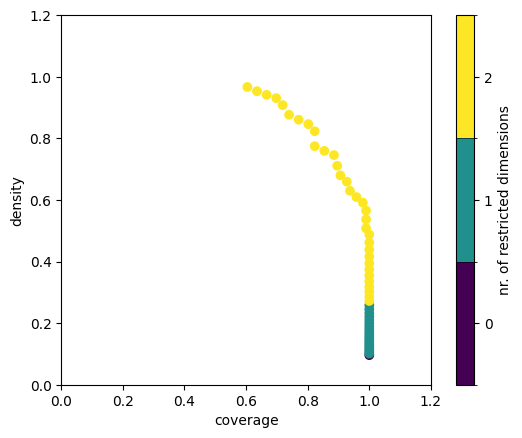

time: 355 ms (started: 2023-10-30 22:04:11 -03:00)


In [17]:
box1.show_tradeoff()
plt.show()

coverage     0.822917
density      0.774510
id          43.000000
mass         0.102000
mean         0.774510
res_dim      2.000000
Name: 43, dtype: float64

     box 43                                 
        min       max      qp value qp value
b  0.364738  0.449735  8.304759e-96      NaN
q  3.474371  4.498667  2.441824e-51      NaN



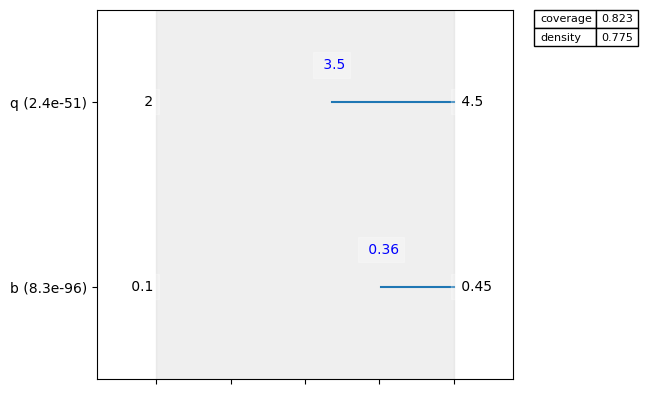

time: 188 ms (started: 2023-10-30 22:04:11 -03:00)


In [18]:
box1.inspect(43)
box1.inspect(43, style='graph')
plt.show()

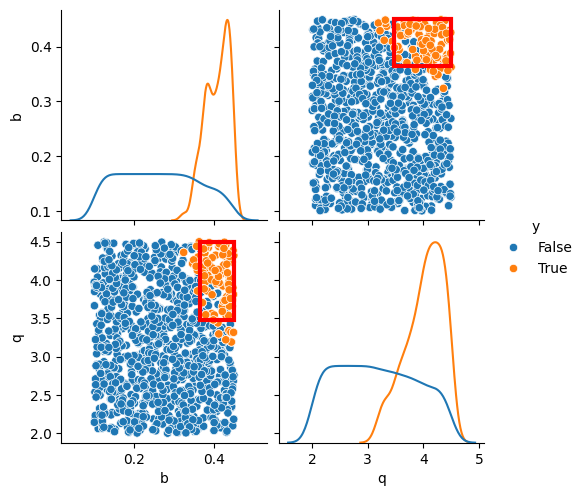

time: 1.81 s (started: 2023-10-30 22:04:11 -03:00)


In [19]:
box1.show_pairs_scatter(43)
plt.show()

[MainProcess/INFO] model dropped from analysis because only a single category
[MainProcess/INFO] model dropped from analysis because only a single category
[MainProcess/INFO] model dropped from analysis because only a single category
[MainProcess/INFO] model dropped from analysis because only a single category


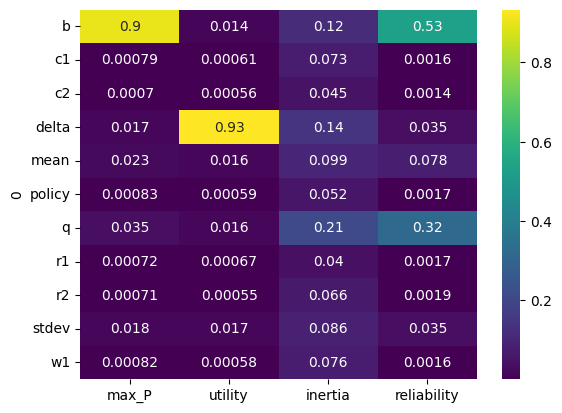

time: 1.95 s (started: 2023-10-30 22:04:13 -03:00)


In [20]:
from ema_workbench.analysis import feature_scoring

x = experiments
y = outcomes

fs = feature_scoring.get_feature_scores_all(x, y)#, mode=feature_scoring.CLASSIFICATION)
sns.heatmap(fs, cmap='viridis', annot=True)
plt.show()

In [21]:
x = experiments
y = outcomes['max_P'] <0.8

fs, alg = feature_scoring.get_ex_feature_scores(x, y)
fs.sort_values(ascending=False, by=1)

[MainProcess/INFO] model dropped from analysis because only a single category


,1
0,
b,0.483228
q,0.325813
mean,0.087956
delta,0.046349
stdev,0.043356
r2,0.002534
c1,0.002422
c2,0.002224
r1,0.002058


time: 403 ms (started: 2023-10-30 22:04:15 -03:00)


In [22]:
from ema_workbench.em_framework.evaluators import Samplers #SOBOL
#from ema_workbench.em_framework.evaluators import MORRIS
print(Samplers.SOBOL)
#print(MORRIS)

Samplers.SOBOL
time: 578 µs (started: 2023-10-30 22:04:16 -03:00)


In [23]:
from SALib.analyze import sobol
from ema_workbench.em_framework.salib_samplers import get_SALib_problem

#with MultiprocessingEvaluator(model) as evaluator:
#    sa_results = evaluator.perform_experiments(scenarios=1024, uncertainty_sampling=SOBOL)#'Sobol')
    # It had to be patched in the source code (uppercase for 'S' in evaluators.py)
sa_results = perform_experiments(models=model, scenarios=1024, uncertainty_sampling=Samplers.SOBOL)

experiments, outcomes = sa_results

problem = get_SALib_problem(model.uncertainties)
Si = sobol.analyze(problem, outcomes['max_P'], calc_second_order=True, print_to_console=False)

[MainProcess/INFO] performing 12288 scenarios * 1 policies * 1 model(s) = 12288 experiments
100%|████████████████████████████████████| 12288/12288 [12:26<00:00, 16.47it/s]
[MainProcess/INFO] experiments finished


time: 12min 26s (started: 2023-10-30 22:04:16 -03:00)


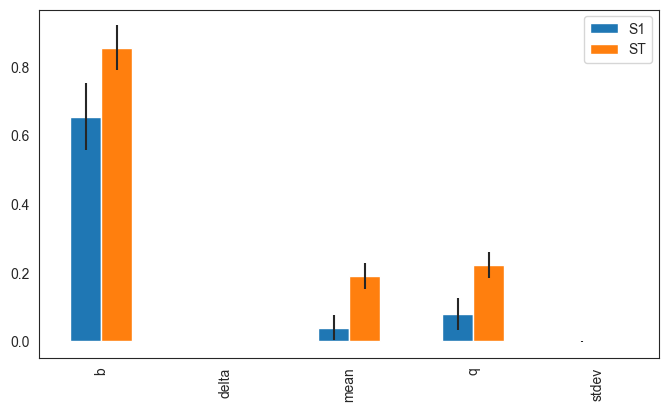

time: 209 ms (started: 2023-10-30 22:16:42 -03:00)


In [24]:
scores_filtered = {k:Si[k] for k in ['ST','ST_conf','S1','S1_conf']}
Si_df = pd.DataFrame(scores_filtered, index=problem['names'])

sns.set_style('white')
fig, ax = plt.subplots(1)

indices = Si_df[['S1','ST']]
err = Si_df[['S1_conf','ST_conf']]

indices.plot.bar(yerr=err.values.T,ax=ax)
fig.set_size_inches(8,6)
fig.subplots_adjust(bottom=0.3)
plt.show()

## **Performance/Reliability/Cost Analysis Model**

In [25]:
def countActiveDevices(d1Services, d2Services, d3Services):
    count_activeDevices = 0
    if d1Services > 0:
        count_activeDevices = count_activeDevices + 1
    if d2Services > 0:
        count_activeDevices = count_activeDevices + 1
    if d3Services > 0:
        count_activeDevices = count_activeDevices + 1

    return count_activeDevices

def getTotalCost(d1Services, d2Services, d3Services, deviceCost, serviceCost):
    count_activeServices = d1Services + d2Services + d3Services
    count_activeDevices = countActiveDevices(d1Services, d2Services, d3Services)

    result = count_activeDevices*deviceCost + count_activeServices*serviceCost
    return result

time: 794 µs (started: 2023-10-30 22:16:42 -03:00)


In [26]:
getTotalCost(3,0,1,20,2)

48

time: 2.5 ms (started: 2023-10-30 22:16:42 -03:00)


In [27]:
import math

def getExecutionTime(d1Services, d2Services, d3Services, lbExecTime, deviceCPUCyles, serviceFailureProb):
    count_activeDevices = countActiveDevices(d1Services, d2Services, d3Services)
    if count_activeDevices == 0:
        count_activeDevices = 1

    result = lbExecTime + (1 - serviceFailureProb/100) * 0.5 * deviceCPUCyles / count_activeDevices
    return math.ceil(result)

time: 956 µs (started: 2023-10-30 22:16:42 -03:00)


In [28]:
getExecutionTime(3,0,1,10,120,30)

31

time: 3.41 ms (started: 2023-10-30 22:16:42 -03:00)


In [29]:
def getProbabilitySuccessfulExecution(d1Services, d2Services, d3Services, lbFailureProb, serviceFailureProb):
    count_activeDevices = countActiveDevices(d1Services, d2Services, d3Services)

    result = 100 * (1 - lbFailureProb/100) * (1 - math.pow(serviceFailureProb/100, count_activeDevices))
    return math.ceil(result)

time: 652 µs (started: 2023-10-30 22:16:42 -03:00)


In [30]:
getProbabilitySuccessfulExecution(3,0,1,20,30)

73

time: 4.15 ms (started: 2023-10-30 22:16:42 -03:00)


In [31]:
Default_deviceCost = 20
Default_serviceCost = 2
Default_lbExectTime = 30
Default_deviceCPUCyles = 120
Default_lbFailureProb = 20
Default_serviceFailureProb = 30
Default_dServices = 1

def modelFunction(d1Services= Default_dServices,
                  d2Services= Default_dServices,
                  d3Services= Default_dServices,
                  deviceCost = Default_deviceCost,
                  serviceCost = Default_serviceCost,
                  lbExecTime = Default_lbExectTime,
                  deviceCPUCyles = Default_deviceCPUCyles,
                  serviceFailureProb = Default_serviceFailureProb,
                  lbFailureProb = Default_lbFailureProb):

    cost = getTotalCost(d1Services, d2Services, d3Services, deviceCost, serviceCost)
    executionTime = getExecutionTime(d1Services, d2Services, d3Services, lbExecTime, deviceCPUCyles, serviceFailureProb)
    probSuccessfulExecution = getProbabilitySuccessfulExecution(d1Services, d2Services, d3Services, lbFailureProb, serviceFailureProb)

    # Outcomes
    return cost, executionTime, probSuccessfulExecution

time: 1.25 ms (started: 2023-10-30 22:16:42 -03:00)


In [32]:
#modelFunction(2,1,0,20,2,10,120,30, 20)
modelFunction(2,1,0)

(46, 51, 73)

time: 3.37 ms (started: 2023-10-30 22:16:42 -03:00)


In [33]:
from ema_workbench import (RealParameter, IntegerParameter, ScalarOutcome, Model)

model = Model('designoptimization', function=modelFunction)

#specify uncertainties
model.uncertainties = [IntegerParameter('deviceCost', 10, 30),
                       IntegerParameter('serviceCost', 1, 5),
                       IntegerParameter('lbExecTime', 10, 50),
                       IntegerParameter('deviceCPUCyles', 100, 150),
                       IntegerParameter('serviceFailureProb', 10, 50),
                       IntegerParameter('lbFailureProb', 10, 50)]

# set levers
model.levers = [IntegerParameter("d1Services", 0, 6), # This is selecting only 1 alternative!
                IntegerParameter("d2Services", 0, 6),
                IntegerParameter("d3Services", 0, 6)]

#specify outcomes
model.outcomes = [ScalarOutcome('cost'),
                  ScalarOutcome('executionTime'),
                  ScalarOutcome('probSuccessfulExecution')]

time: 8.87 ms (started: 2023-10-30 22:16:42 -03:00)


In [34]:
from ema_workbench import (MultiprocessingEvaluator, ema_logging, perform_experiments)
ema_logging.log_to_stderr(ema_logging.INFO)

#with MultiprocessingEvaluator(model) as evaluator:
#    results = evaluator.perform_experiments(scenarios=100, policies=10)
results = perform_experiments(models=model, scenarios=100, policies=300)

[MainProcess/INFO] performing 100 scenarios * 300 policies * 1 model(s) = 30000 experiments
100%|██████████████████████████████████| 30000/30000 [00:07<00:00, 3963.64it/s]
[MainProcess/INFO] experiments finished


time: 7.61 s (started: 2023-10-30 22:16:42 -03:00)


In [35]:
experiments, outcomes = results
print(experiments.shape)
print(list(outcomes.keys()))

(30000, 12)
['cost', 'executionTime', 'probSuccessfulExecution']
time: 490 µs (started: 2023-10-30 22:16:50 -03:00)


In [36]:
experiments

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model
0,131,21,20,48,3,10,4,5,4,13591,13291,designoptimization
1,138,10,46,30,3,31,4,5,4,13592,13291,designoptimization
2,114,25,48,40,1,14,4,5,4,13593,13291,designoptimization
3,102,23,43,23,4,39,4,5,4,13594,13291,designoptimization
4,126,30,19,26,1,13,4,5,4,13595,13291,designoptimization
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,133,26,41,46,5,36,6,6,4,13686,13590,designoptimization
29996,107,10,50,45,1,27,6,6,4,13687,13590,designoptimization
29997,143,30,32,39,1,29,6,6,4,13688,13590,designoptimization
29998,128,11,13,10,5,44,6,6,4,13689,13590,designoptimization


time: 12.1 ms (started: 2023-10-30 22:16:50 -03:00)


In [37]:
import numpy as np
import pandas as pd

policies = experiments['policy']
#for i, policy in enumerate(np.unique(policies)):
#    experiments.loc[policies==policy, 'policy'] = str(i)

data = pd.DataFrame(outcomes)
data['policy'] = policies

time: 1.68 ms (started: 2023-10-30 22:16:50 -03:00)


In [38]:
#set(experiments['policy'])
#set(experiments['scenario'])

time: 233 µs (started: 2023-10-30 22:16:50 -03:00)


In [39]:
experiments['policy'] = experiments.policy.astype(str)

time: 8.41 ms (started: 2023-10-30 22:16:50 -03:00)


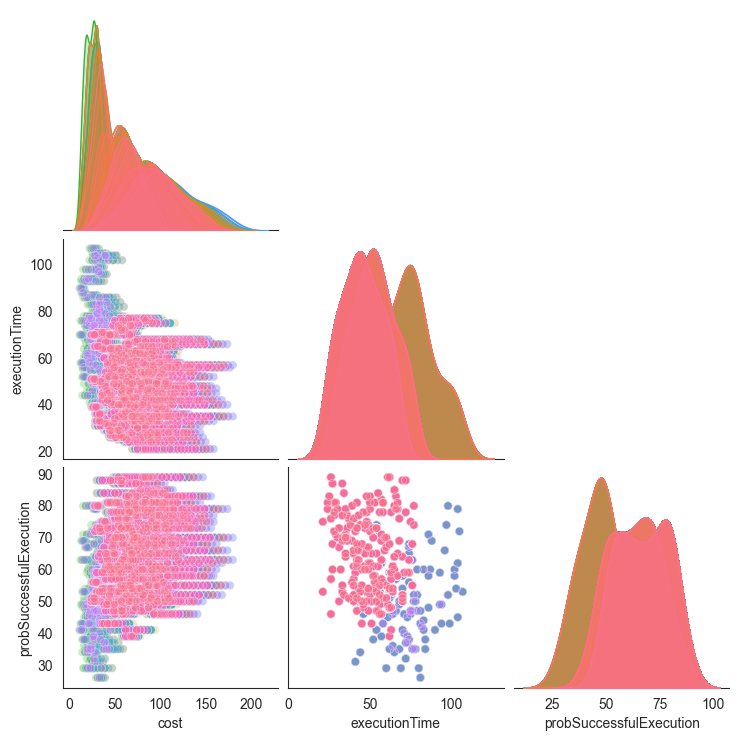

time: 17.1 s (started: 2023-10-30 22:16:50 -03:00)


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.pairplot(data, hue='policy', vars=list(outcomes.keys()), corner=True, plot_kws={'alpha':0.25})
g._legend.remove()
plt.savefig('single-configurations-210.png')
plt.show()

[MainProcess/INFO] no time dimension found in results


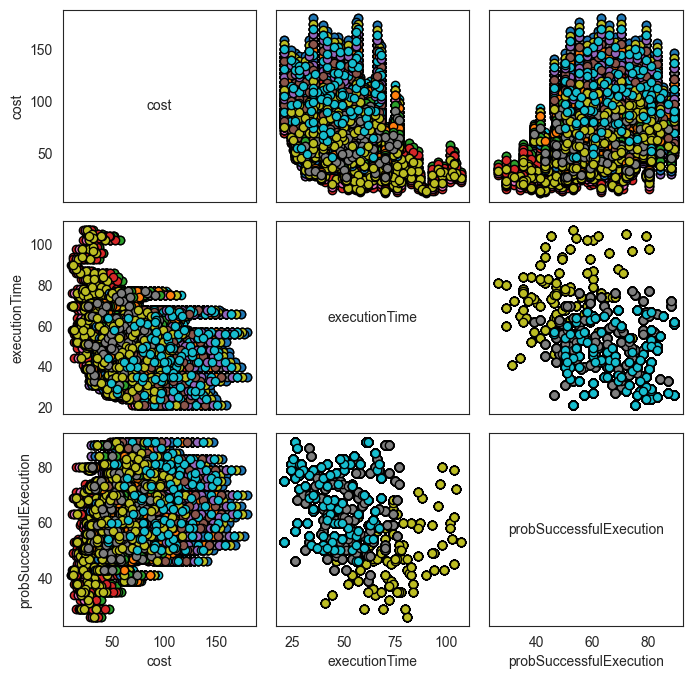

time: 30.8 s (started: 2023-10-30 22:17:07 -03:00)


In [41]:
from ema_workbench.analysis import pairs_plotting

fig, axes = pairs_plotting.pairs_scatter(experiments, outcomes, group_by='policy',legend=False)
fig.set_size_inches(8,8)
plt.savefig('all-configurations-uncertainty.png')
plt.show()

In [42]:
from ema_workbench.analysis import prim

x = experiments
y = outcomes['executionTime'] < 40
prim_alg = prim.Prim(x, y, threshold=0.2)
box1 = prim_alg.find_box()

[MainProcess/INFO] model dropped from analysis because only a single category
[MainProcess/INFO] 30000 points remaining, containing 7947 cases of interest
[MainProcess/INFO] mean: 1.0, mass: 0.1827, coverage: 0.6896942242355606, density: 1.0 restricted_dimensions: 7


time: 15.2 s (started: 2023-10-30 22:17:38 -03:00)


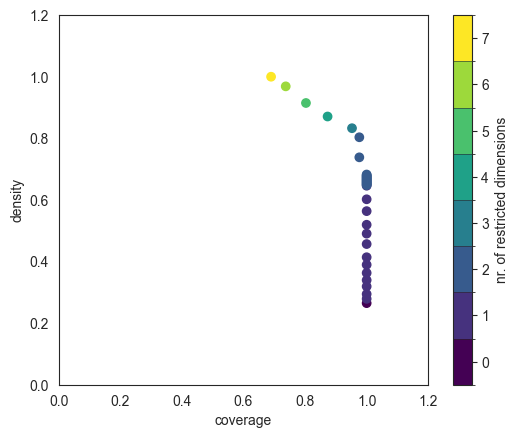

time: 290 ms (started: 2023-10-30 22:17:53 -03:00)


In [43]:
box1.show_tradeoff()
plt.show()

In [44]:
#box1.box_lims

time: 252 µs (started: 2023-10-30 22:17:53 -03:00)


coverage    1.000000
density     0.294333
id          2.000000
mass        0.900000
mean        0.294333
res_dim     1.000000
Name: 2, dtype: float64

           box 2                             
             min   max qp value      qp value
lbExecTime  10.0  46.0      NaN  1.215695e-27



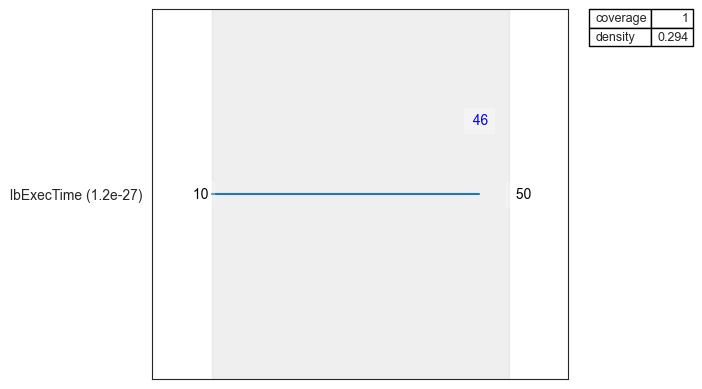

time: 133 ms (started: 2023-10-30 22:17:53 -03:00)


In [45]:
n = 2
box1.inspect(n)
box1.inspect(n, style='graph')
plt.show()

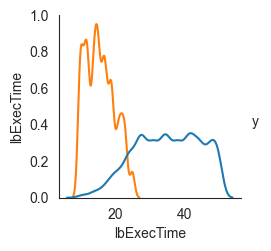

time: 590 ms (started: 2023-10-30 22:17:53 -03:00)


In [46]:
box1.show_pairs_scatter(n)
plt.show()

[MainProcess/INFO] model dropped from analysis because only a single category
[MainProcess/INFO] model dropped from analysis because only a single category
[MainProcess/INFO] model dropped from analysis because only a single category


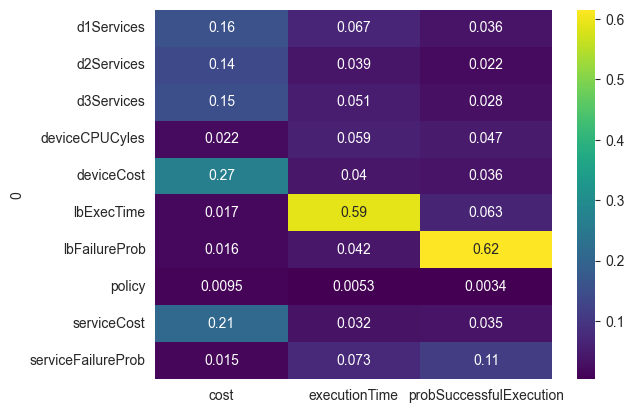

time: 4.38 s (started: 2023-10-30 22:17:54 -03:00)


In [47]:
from ema_workbench.analysis import feature_scoring

x = experiments
y = outcomes

fs = feature_scoring.get_feature_scores_all(x, y)#, mode=feature_scoring.CLASSIFICATION)
sns.heatmap(fs, cmap='viridis', annot=True)
plt.savefig('feature-scoring.png')
plt.show()

In [48]:
from ema_workbench.analysis import prim

x = experiments
y = (outcomes['cost'] > 70) #& (outcomes['executionTime'] < 25)
prim_alg = prim.Prim(x, y, threshold=0.8)
box1 = prim_alg.find_box()

[MainProcess/INFO] model dropped from analysis because only a single category
[MainProcess/INFO] 30000 points remaining, containing 17143 cases of interest
[MainProcess/INFO] mean: 1.0, mass: 0.248, coverage: 0.43399638336347196, density: 1.0 restricted_dimensions: 5


time: 1min 40s (started: 2023-10-30 22:17:58 -03:00)


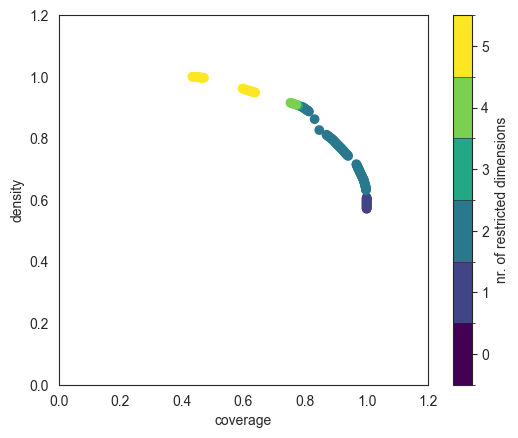

time: 446 ms (started: 2023-10-30 22:19:39 -03:00)


In [49]:
box1.show_tradeoff()
plt.savefig('prim-tradeoff.png')
plt.show()

/Users/adiazpace/opt/anaconda3/envs/robustopt/lib/python3.11/site-packages/ema_workbench/analysis/scenario_discovery_util.py:413: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


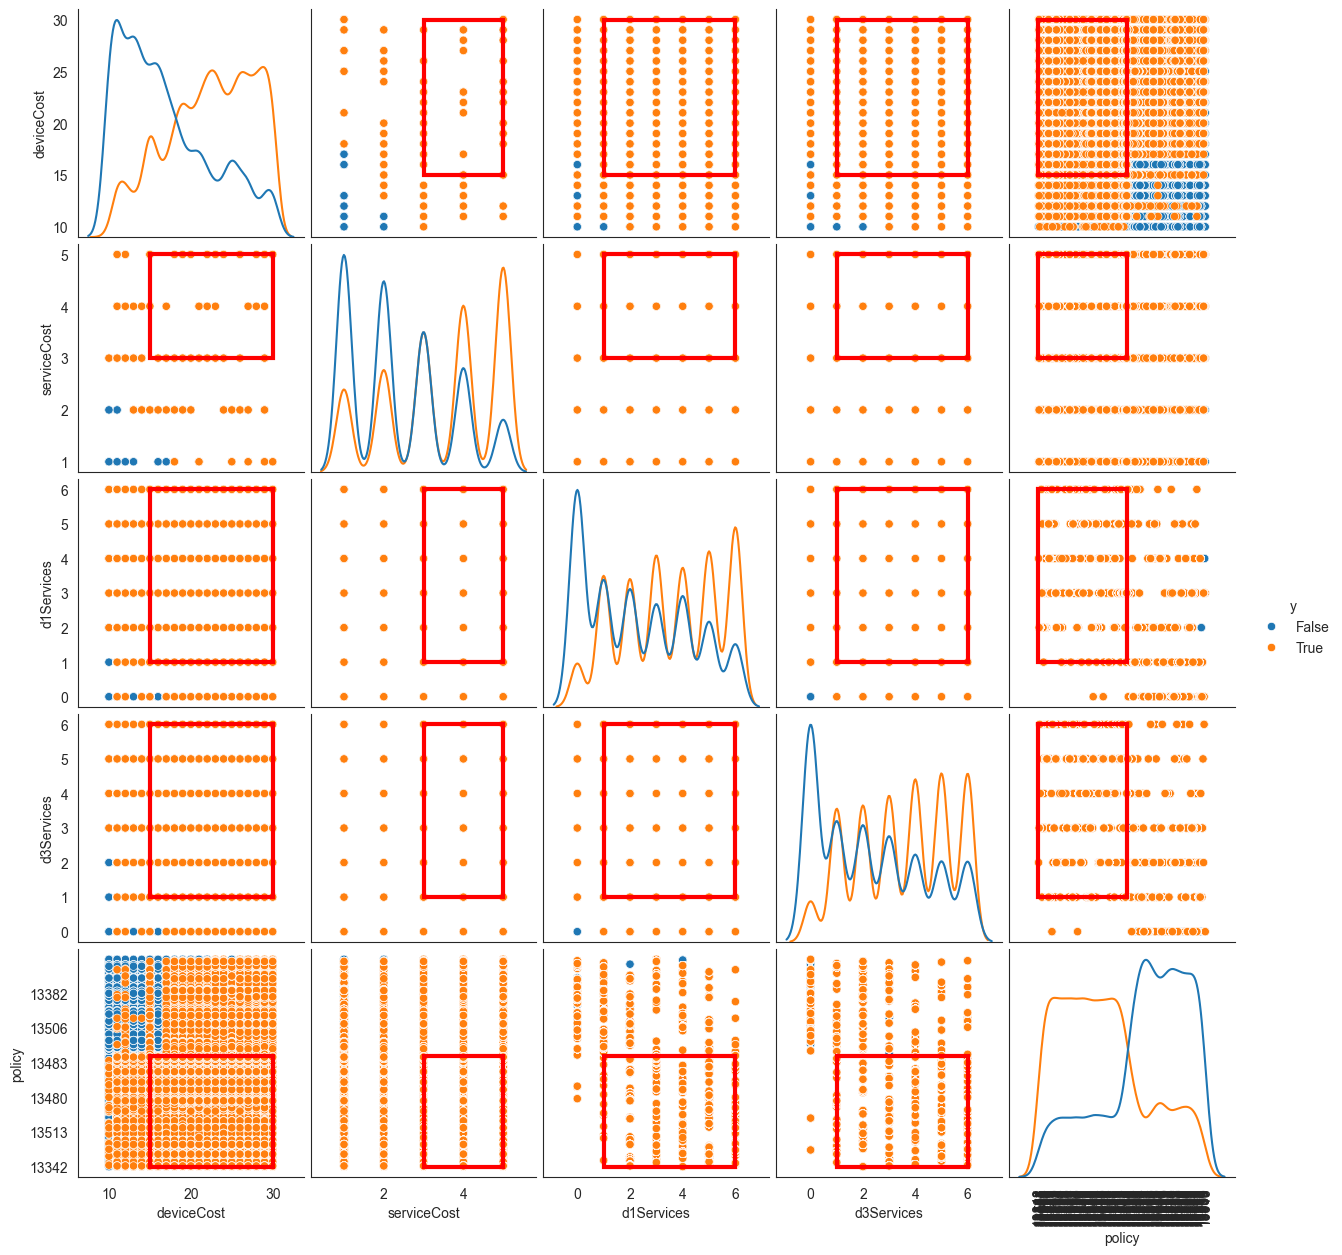

time: 1min 3s (started: 2023-10-30 22:19:40 -03:00)


In [50]:
box1.show_pairs_scatter()
plt.savefig('prim-boxes.png')
plt.show()

In [51]:
x = experiments
y = outcomes['cost'] < 70

fs, alg = feature_scoring.get_ex_feature_scores(x, y)
fs.sort_values(ascending=False, by=1)

[MainProcess/INFO] model dropped from analysis because only a single category


,1
0,
deviceCost,0.253202
serviceCost,0.159524
d3Services,0.155655
d1Services,0.153375
d2Services,0.148332
deviceCPUCyles,0.034140
lbExecTime,0.028610
serviceFailureProb,0.024779
lbFailureProb,0.024727


time: 1.34 s (started: 2023-10-30 22:20:44 -03:00)


In [52]:
print(model.levers.keys())

odict_keys(['d1Services', 'd2Services', 'd3Services'])
time: 582 µs (started: 2023-10-30 22:20:45 -03:00)


In [53]:
from SALib.analyze import sobol
from ema_workbench.em_framework.salib_samplers import get_SALib_problem
from ema_workbench import Policy

#policy = Policy('no release', **{str(i): 0.1 for i in range(100)})

#with MultiprocessingEvaluator(model) as evaluator:
#    sa_results = evaluator.perform_experiments(scenarios= None, #1024,
#                              policies= 1024,
#                              #uncertainty_sampling=SOBOL)
#                              levers_sampling= SOBOL)#'Sobol')
    # It had to be patched in the source code (uppercase for 'S' in evaluators.py)
sa_results = perform_experiments(models=model, scenarios=128,
                              policies=1, #128,
                              uncertainty_sampling= Samplers.SOBOL)#'Sobol')

experiments, outcomes = sa_results

[MainProcess/INFO] performing 1792 scenarios * 1 policies * 1 model(s) = 1792 experiments
100%|████████████████████████████████████| 1792/1792 [00:00<00:00, 3803.26it/s]
[MainProcess/INFO] experiments finished


time: 498 ms (started: 2023-10-30 22:20:45 -03:00)


In [54]:
experiments

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model
0,119,28,32,12,5,37,3,6,2,13692,13691,designoptimization
1,136,28,32,12,5,37,3,6,2,13693,13691,designoptimization
2,119,30,32,12,5,37,3,6,2,13694,13691,designoptimization
3,119,28,25,12,5,37,3,6,2,13695,13691,designoptimization
4,119,28,32,41,5,37,3,6,2,13696,13691,designoptimization
...,...,...,...,...,...,...,...,...,...,...,...,...
1787,125,28,27,27,4,21,3,6,2,15479,13691,designoptimization
1788,125,28,18,36,4,21,3,6,2,15480,13691,designoptimization
1789,125,28,18,27,4,21,3,6,2,15481,13691,designoptimization
1790,125,28,18,27,4,41,3,6,2,15482,13691,designoptimization


time: 10.4 ms (started: 2023-10-30 22:20:45 -03:00)


In [69]:
problem = get_SALib_problem(model.uncertainties)
#problem = get_SALib_problem(model.levers)
#Si = sobol.analyze(problem, outcomes['probSuccessfulExecution'], calc_second_order=False, print_to_console=False)
#Si = sobol.analyze(problem, outcomes['probSuccessfulExecution'], calc_second_order=True, print_to_console=False)
Si = sobol.analyze(problem, outcomes['cost'], calc_second_order=False, print_to_console=False)
#Si = sobol.analyze(problem, outcomes['executionTime'], calc_second_order=False, print_to_console=False)

time: 62.1 ms (started: 2023-10-30 22:25:36 -03:00)


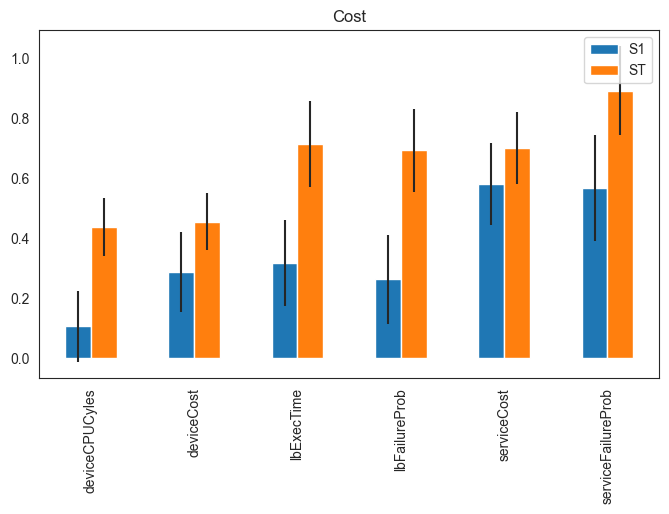

time: 313 ms (started: 2023-10-30 22:25:37 -03:00)


In [70]:
scores_filtered = {k:Si[k] for k in ['ST','ST_conf','S1','S1_conf']}
Si_df = pd.DataFrame(scores_filtered, index=problem['names'])

sns.set_style('white')
fig, ax = plt.subplots(1)

indices = Si_df[['S1','ST']]
err = Si_df[['S1_conf','ST_conf']]

indices.plot.bar(yerr=err.values.T,ax=ax)
fig.set_size_inches(8,6)
fig.subplots_adjust(bottom=0.3)
plt.savefig('sobol-cost.png')
plt.title('Cost')
plt.show()